# Phân tích và Trực quan hóa Dữ liệu Chunks

Notebook này dùng để đọc và phân tích file `langchain_chunks.json` - là kết quả cuối cùng của quá trình tiền xử lý và chia văn bản.

**Mục tiêu:**
1.  Đọc dữ liệu chunks đã lưu.
2.  Tính toán các thông số thống kê quan trọng về các chunks.
3.  Trực quan hóa sự phân phối độ dài của các chunks để đánh giá kết quả của quá trình chunking.

In [1]:
import json
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np

# Thiết lập đường dẫn
BASE_DIR = Path(r"C:\Users\ASUS-PRO\Desktop\Traffic_Law_Chatbot")
PROCESSED_DIR = BASE_DIR / "data" / "processed"
CHUNK_FILE = PROCESSED_DIR / "langchain_chunks.json"

print(f"Đường dẫn file chunk: {CHUNK_FILE}")

Đường dẫn file chunk: C:\Users\ASUS-PRO\Desktop\Traffic_Law_Chatbot\data\processed\langchain_chunks.json


In [2]:
# --- 1. Đọc dữ liệu chunks từ file JSON ---
print("Bắt đầu đọc file chunks...")
try:
    with open(CHUNK_FILE, "r", encoding="utf-8") as f:
        data = json.load(f)
    
    chunks = data.get("chunks", [])
    metadata = data.get("metadata", {})
    
    if not chunks:
        print("⚠️ Cảnh báo: Không tìm thấy 'chunks' trong file JSON.")
    else:
        print(f"✓ Đã đọc thành công {len(chunks):,} chunks.")

except FileNotFoundError:
    print(f"❌ Lỗi: Không tìm thấy file tại đường dẫn: {CHUNK_FILE}")
    chunks = []
    metadata = {}
except json.JSONDecodeError:
    print(f"❌ Lỗi: File JSON không hợp lệ: {CHUNK_FILE}")
    chunks = []
    metadata = {}


Bắt đầu đọc file chunks...
✓ Đã đọc thành công 393 chunks.


In [3]:
# --- 2. Tính toán các thông số thống kê ---
if chunks:
    # Tính độ dài (số từ) của mỗi chunk
    chunk_lengths = [len(c.split()) for c in chunks]

    # Tính các giá trị thống kê
    total_chunks = len(chunks)
    avg_len = np.mean(chunk_lengths)
    max_len = np.max(chunk_lengths)
    min_len = np.min(chunk_lengths)
    std_dev = np.std(chunk_lengths)

    print("=" * 50)
    print("📊 THỐNG KÊ CHI TIẾT VỀ CÁC CHUNKS")
    print("=" * 50)
    print(f"   - Tổng số chunks:           {total_chunks:,}")
    print(f"   - Độ dài trung bình/chunk:  {avg_len:.2f} từ")
    print(f"   - Độ lệch chuẩn:            {std_dev:.2f} từ")
    print(f"   - Chunk dài nhất:           {max_len:,} từ")
    print(f"   - Chunk ngắn nhất:          {min_len:,} từ")
    print("-" * 50)
    print("Thông tin từ metadata:")
    print(f"   - Chunk Size (tham số):    {metadata.get('chunk_size', 'N/A')}")
    print(f"   - Chunk Overlap (tham số): {metadata.get('chunk_overlap', 'N/A')}")


📊 THỐNG KÊ CHI TIẾT VỀ CÁC CHUNKS
   - Tổng số chunks:           393
   - Độ dài trung bình/chunk:  219.88 từ
   - Độ lệch chuẩn:            7.88 từ
   - Chunk dài nhất:           241 từ
   - Chunk ngắn nhất:          186 từ
--------------------------------------------------
Thông tin từ metadata:
   - Chunk Size (tham số):    1000
   - Chunk Overlap (tham số): 150


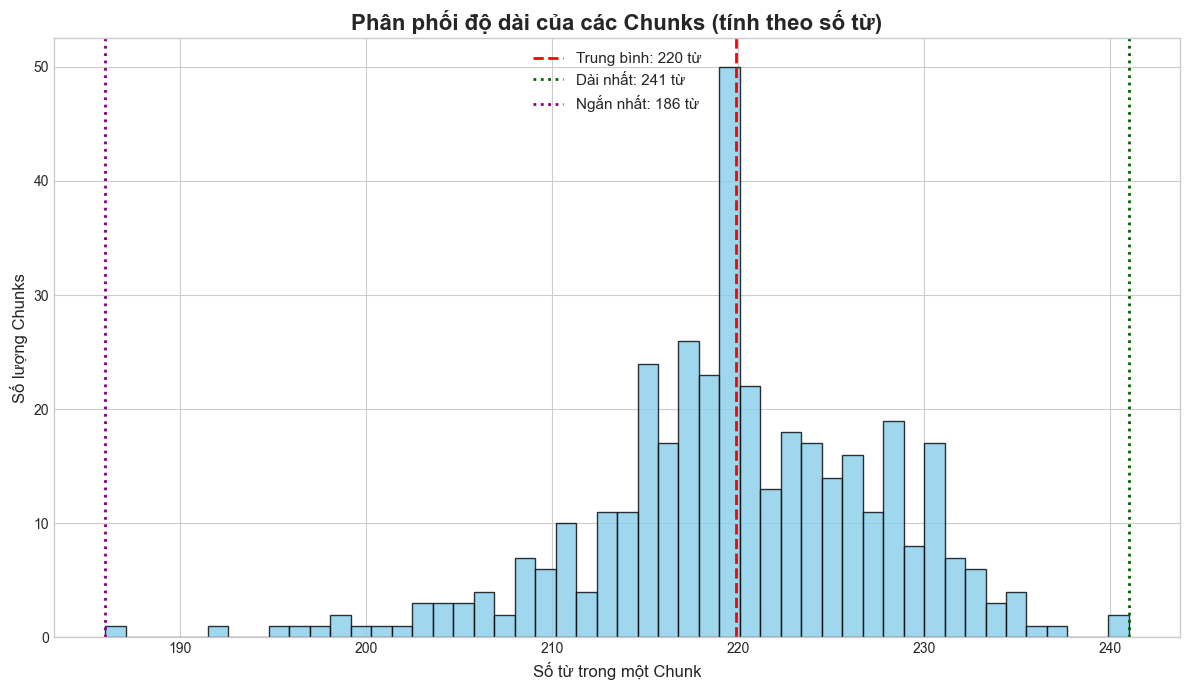

In [4]:
# --- 3. Trực quan hóa phân phối độ dài chunks ---
if chunks:
    plt.style.use('seaborn-v0_8-whitegrid')
    fig, ax = plt.subplots(figsize=(12, 7))

    # Vẽ histogram
    ax.hist(chunk_lengths, bins=50, color='skyblue', edgecolor='black', alpha=0.8)

    # Thêm các đường trung bình, min, max
    ax.axvline(avg_len, color='red', linestyle='--', linewidth=2, label=f'Trung bình: {avg_len:.0f} từ')
    ax.axvline(max_len, color='darkgreen', linestyle=':', linewidth=2, label=f'Dài nhất: {max_len} từ')
    ax.axvline(min_len, color='purple', linestyle=':', linewidth=2, label=f'Ngắn nhất: {min_len} từ')

    # Thiết lập tiêu đề và nhãn
    ax.set_title('Phân phối độ dài của các Chunks (tính theo số từ)', fontsize=16, fontweight='bold')
    ax.set_xlabel('Số từ trong một Chunk', fontsize=12)
    ax.set_ylabel('Số lượng Chunks', fontsize=12)
    ax.legend(fontsize=11)
    ax.grid(True)

    # Hiển thị biểu đồ
    plt.tight_layout()
    plt.show()